<a href="https://colab.research.google.com/github/SawantSameer/csot-ml-astronomy/blob/main/Submissions/SameerSawant/week1/part2_myAttempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 — ML in Astronomy — Week 1 · Part 2: Data Pipeline (Starter)

**Goal:** Get the Galaxy Zoo 2 images flowing through a PyTorch data pipeline and *look at them*.

By the end you'll join the official morphology labels to flat image files, build an `ImageFolder`-ready layout, create a `DataLoader` yielding `(32, 3, 64, 64)` batches, and plot a matplotlib grid of real galaxies.

**Before you begin:**
1. Finish **Part 1** (`week1_starter.ipynb`) first.
2. Switch this notebook to a **GPU runtime** (`Runtime → Change runtime type → GPU`). Not strictly required for data loading, but keeps you consistent.
3. Read [`08-data-pipelines.md`](../08-data-pipelines.md) — every TODO below maps to a section there.

> **Heads-up:** The [Kaggle Galaxy Zoo 2 download](https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images) does **not** ship class subfolders. Images are named `{asset_id}.jpg` in a flat folder; labels live in CSV catalogues. We join them first, then use `ImageFolder`.

Attempt every TODO before opening `week1_data_solution.ipynb`.

## Step 0 — Imports

In [24]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 — Get the dataset into Colab

The Kaggle bundle contains:
- `images_gz2.zip` — ~243k JPGs named `1.jpg`, `2.jpg`, … (no class folders)
- `gz2_filename_mapping.csv` — maps each `asset_id` to an SDSS `objid`

Morphology labels come separately from the official GZ2 catalogue ([Hart et al. 2016](https://data.galaxyzoo.org/)), which we download as `gz2_hart16.csv.gz`.

**Option A — Kaggle API (recommended).** Upload your `kaggle.json` token, then run the download/unzip commands in the solution notebook (or adapt the cell below).

Fill in the cell below to download/locate the data and set the paths.

In [25]:
import os
import json
import shutil
from pathlib import Path

# --- 1. KAGGLE AUTHENTICATION ---
# Replace with your EXACT username and key from your Kaggle account
kaggle_creds = {
  "username": "your_username_here",
  "key": "your_long_alphanumeric_key_here"
}

# Create the hidden Kaggle directory and write the credentials file
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

# Lock down the file permissions for security
!chmod 600 /root/.kaggle/kaggle.json

# --- 2. DIRECTORY SETUP ---
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"
DATA_ROOT = Path("galaxy_data")
RAW_ROOT.mkdir(parents=True, exist_ok=True)

# --- 3. DOWNLOAD KAGGLE IMAGES ---
print("Authenticating and downloading images from Kaggle. This might take a minute...")
dataset_name = "jaimetrickz/galaxy-zoo-2-images"
!kaggle datasets download -d {dataset_name} -p {RAW_ROOT} --unzip

# --- 4. DOWNLOAD HART LABELS ---
print("Downloading Hart et al. morphology labels...")
!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

# --- 5. FIX NESTED DIRECTORY ---
# Kaggle sometimes double-wraps the extracted folder. This flattens it.
nested_dir = IMAGES_DIR / "images_gz2"

if nested_dir.exists() and nested_dir.is_dir():
    print("Flattening the nested image directory...")
    for file in nested_dir.glob("*.jpg"):
        shutil.move(str(file), str(IMAGES_DIR))
    nested_dir.rmdir() # Clean up the empty duplicate folder

import shutil
from pathlib import Path

RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"

print("Hunting for the hidden images...")

# Recursively find ALL jpg files anywhere inside RAW_ROOT
all_jpgs = list(RAW_ROOT.rglob("*.jpg"))
print(f"Found {len(all_jpgs)} total images hiding in the raw folder!")

if len(all_jpgs) > 0:
    print("Moving them to the correct IMAGES_DIR... (This might take a minute)")

    # Ensure IMAGES_DIR exists
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)

    # Move them all to the flat directory
    moved_count = 0
    for img_path in all_jpgs:
        # Only move if it's not already in the right spot
        if img_path.parent != IMAGES_DIR:
            shutil.move(str(img_path), str(IMAGES_DIR / img_path.name))
            moved_count += 1

    print(f"Successfully moved {moved_count} images!")

# Final Recount
print("\n--- Final Image Recount ---")
image_count = len(list(IMAGES_DIR.glob('*.jpg')))
print(f"Total images exactly in target folder: {image_count}")

if image_count > 240000:
    print("✅ Found them! Data pipeline setup successful! Ready for Step 2.")
else:
    print("⚠️ Warning: Something is still odd. Let me know what it prints!")



# --- 6. FINAL SANITY CHECK ---
print("\n--- Final Download Check ---")
print(f"Mapping CSV exists: {(RAW_ROOT / 'gz2_filename_mapping.csv').exists()}")
print(f"Hart labels CSV exists: {(RAW_ROOT / 'gz2_hart16.csv').exists()}")
print(f"Images folder exists: {IMAGES_DIR.exists()}")

if IMAGES_DIR.exists():
    image_count = len(list(IMAGES_DIR.glob('*.jpg')))
    print(f"Total images found: {image_count}")
    if image_count > 240000:
        print("✅ Data pipeline setup successful! Ready for Step 2.")
    else:
        print("⚠️ Warning: Image count seems low.")

Authenticating and downloading images from Kaggle. This might take a minute...
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [03:00<00:00, 18.2MB/s]

Hunting for the hidden images...
Found 486868 total images hiding in the raw folder!
Moving them to the correct IMAGES_DIR... (This might take a minute)
Successfully moved 243434 images!

--- Final Image Recount ---
Total images exactly in target folder: 243434
✅ Found them! Data pipeline setup successful! Ready for Step 2.

--- Final Download Check ---
Mapping CSV exists: True
Hart labels CSV exists: True
Images folder exists: True
Total images found: 243434
✅ Data pipeline setup successful! Ready for Step 2.


## Step 2 — Inspect the raw layout

List what's inside `RAW_ROOT` and peek at `IMAGES_DIR`. You should see a CSV mapping file and many JPGs named by integer ID — **not** morphology subfolders.

Also open `gz2_filename_mapping.csv` and confirm columns `objid`, `sample`, `asset_id`.

In [26]:
# TODO: print os.listdir(RAW_ROOT) and count a few files in IMAGES_DIR.
#       Hint: Path(IMAGES_DIR).glob("*.jpg")
import pandas as pd
from pathlib import Path

# Assuming these are still set from the previous cell
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"

print("--- 1. Contents of RAW_ROOT ---")
# List everything sitting in the raw folder
for item in RAW_ROOT.iterdir():
    print(f" - {item.name}")

print("\n--- 2. Peek at IMAGES_DIR ---")
# Grab just the first 5 jpg files to verify the naming convention
sample_images = list(IMAGES_DIR.glob('*.jpg'))[:5]
for img in sample_images:
    print(f" - {img.name}")

print("\n--- 3. Checking gz2_filename_mapping.csv ---")
mapping_csv_path = RAW_ROOT / "gz2_filename_mapping.csv"

if mapping_csv_path.exists():
    # Load the CSV into a pandas DataFrame
    df_mapping = pd.read_csv(mapping_csv_path)

    print("Columns found:")
    print(df_mapping.columns.tolist())

    print("\nFirst 3 rows:")
    # Display the first few rows to see the actual data
    display(df_mapping.head(3))

    # Programmatic check for the specific columns
    expected_cols = {'objid', 'sample', 'asset_id'}
    actual_cols = set(df_mapping.columns)

    if expected_cols.issubset(actual_cols):
        print("\n✅ Success: Expected columns (objid, sample, asset_id) are all present!")
    else:
        print("\n⚠️ Warning: Missing expected columns.")
else:
    print(f"⚠️ Error: Could not find {mapping_csv_path}")

--- 1. Contents of RAW_ROOT ---
 - images_gz2
 - gz2_filename_mapping.csv
 - gz2_hart16.csv

--- 2. Peek at IMAGES_DIR ---
 - 135418.jpg
 - 179026.jpg
 - 62305.jpg
 - 217760.jpg
 - 180837.jpg

--- 3. Checking gz2_filename_mapping.csv ---
Columns found:
['objid', 'sample', 'asset_id']

First 3 rows:


,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3



✅ Success: Expected columns (objid, sample, asset_id) are all present!


## Step 3 — Join labels and build an ImageFolder layout

`ImageFolder` expects `root/<class_name>/<image>.jpg`. Our Kaggle download doesn't provide that, so we:

1. Merge `gz2_filename_mapping.csv` with `gz2_hart16.csv` on `objid`.
2. Collapse the detailed `gz2_class` string (e.g. `Sc2t`, `Ei`) into a few high-level buckets.
3. Symlink a **balanced subset** into `DATA_ROOT/<class>/` so Colab stays fast.

Implement `high_level_label(gz2_class)` and `build_imagefolder_layout(...)` — see [`08-data-pipelines.md`](../08-data-pipelines.md).

In [27]:
# TODO: define high_level_label(gz2_class) -> str | None
#       E* -> "elliptical", SB* -> "spiral_barred", S* -> "spiral"; skip "A" (artifact)
import pandas as pd
import os
import shutil
from pathlib import Path
# --- 1. Define the Label Mapping Function ---
def high_level_label(gz2_class):
    """Maps detailed GZ2 class strings to our high-level buckets."""
    if not isinstance(gz2_class, str):
        return None

    class_upper = gz2_class.upper()

    if class_upper.startswith('E'):
        return "elliptical"
    # MUST check SB before S so Barred Spirals aren't misclassified!
    elif class_upper.startswith('SB'):
        return "spiral_barred"
    elif class_upper.startswith('S'):
        return "spiral"
    # Optional: Lenticulars (S0) and Irregulars (I) if you want to include them
    elif class_upper.startswith('S0'):
        return "lenticular"
    elif class_upper.startswith('I'):
        return "irregular"
    else:
        # Skips artifacts ('A') or anything unrecognized
        return None

# TODO: define build_imagefolder_layout(...) that merges CSVs and symlinks
#       PER_CLASS images per class into DATA_ROOT/<label>/.
#       Call it once with PER_CLASS = 200 (or similar).
def build_imagefolder_layout(images_dir, mapping_csv, hart_csv, dest_dir, per_class=200):
    print("Loading CSV files...")
    df_map = pd.read_csv(mapping_csv)
    df_hart = pd.read_csv(hart_csv)

    print("Merging dataframes on 'objid'...")
    # left_on refers to df_map, right_on refers to df_hart
    df = pd.merge(df_map, df_hart, left_on="objid", right_on="dr7objid")

    print("Applying morphology labels...")
    df['label'] = df['gz2_class'].apply(high_level_label)

    # Drop rows that returned None (artifacts or unlabeled)
    df = df.dropna(subset=['label'])

    # If the destination directory already exists from a previous run, clear it to avoid symlink crash
    if dest_dir.exists():
        shutil.rmtree(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nBuilding ImageFolder structure with {per_class} images per class...")
    # Group by our new labels
    for label, group in df.groupby('label'):
        # Make sure we don't try to sample more images than actually exist in the class
        n_samples = min(len(group), per_class)
        sampled_group = group.sample(n=n_samples, random_state=42) # Set random_state for reproducibility

        # Create the subfolder for this class
        class_dir = dest_dir / label
        class_dir.mkdir(exist_ok=True)

        valid_links = 0
        for _, row in sampled_group.iterrows():
            asset_id = str(row['asset_id'])
            src_file = images_dir / f"{asset_id}.jpg"
            dest_file = class_dir / f"{asset_id}.jpg"

            # Create symlink if the original image exists
            if src_file.exists():
                os.symlink(src_file, dest_file)
                valid_links += 1

        print(f" ✅ Linked {valid_links} images into DATA_ROOT/{label}/")

# --- 3. Execute the Builder ---
PER_CLASS = 200
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"
DATA_ROOT = Path("galaxy_data")

build_imagefolder_layout(
    images_dir=IMAGES_DIR,
    mapping_csv=RAW_ROOT / "gz2_filename_mapping.csv",
    hart_csv=RAW_ROOT / "gz2_hart16.csv",
    dest_dir=DATA_ROOT,
    per_class=PER_CLASS
)

Loading CSV files...
Merging dataframes on 'objid'...
Applying morphology labels...

Building ImageFolder structure with 200 images per class...
 ✅ Linked 200 images into DATA_ROOT/elliptical/
 ✅ Linked 200 images into DATA_ROOT/spiral/
 ✅ Linked 200 images into DATA_ROOT/spiral_barred/


In [28]:
import pandas as pd
from pathlib import Path

hart_csv = Path("galaxy_raw") / "gz2_hart16.csv"
df_hart = pd.read_csv(hart_csv)

# Print the first 10 column names to see what we are working with
print("Hart catalog columns:")
print(df_hart.columns.tolist()[:10])

Hart catalog columns:
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count']


## Step 4 — Build the transforms pipeline

Compose: `Resize((64, 64))` → `ToTensor()` → `Normalize([0.5]*3, [0.5]*3)`.
See [`08-data-pipelines.md`](../08-data-pipelines.md) for why each step exists and why order matters.

In [29]:
# TODO: transform = transforms.Compose([... Resize, ToTensor, Normalize ...])
import torchvision.transforms as transforms

# Define the transformation pipeline
galaxy_transforms = transforms.Compose([
    # 1. Shrink the massive 424x424 images down to a manageable size
    transforms.Resize((64, 64)),

    # 2. Convert the image to a PyTorch Tensor and scale values from 0-255 to 0.0-1.0
    transforms.ToTensor(),

    # 3. Shift the values to range between -1.0 and 1.0 across all 3 RGB channels
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("✅ Transforms pipeline built!")

✅ Transforms pipeline built!


## Step 5 — Wrap it in an ImageFolder

Create `dataset = ImageFolder(root=DATA_ROOT, transform=transform)`. Print `len(dataset)`, `dataset.classes`, and `dataset.class_to_idx`.

*Remember:* classes are assigned **alphabetically** — and only exist because we created the subfolders in Step 3.

In [30]:
# TODO: create the ImageFolder and print len / classes / class_to_idx.
from torchvision.datasets import ImageFolder

# Create the dataset, passing in the root directory and the transforms we just built
dataset = ImageFolder(root=DATA_ROOT, transform=galaxy_transforms)

print(f"Total images in dataset: {len(dataset)}")
print(f"Classes found:{dataset.classes}")
print(f"Classes to Index mapping: {dataset.class_to_idx}")


Total images in dataset: 600
Classes found:['elliptical', 'spiral', 'spiral_barred']
Classes to Index mapping: {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


In [31]:
# A code to fix the symlink!
import shutil
from pathlib import Path

# 1. Delete the broken folder
DATA_ROOT = Path("galaxy_data")
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)

# 2. Grab the ABSOLUTE paths using .resolve()
RAW_ROOT = Path("galaxy_raw").resolve()
IMAGES_DIR = RAW_ROOT / "images_gz2"

# 3. Re-run your exact builder function with the absolute paths
build_imagefolder_layout(
    images_dir=IMAGES_DIR,
    mapping_csv=RAW_ROOT / "gz2_filename_mapping.csv",
    hart_csv=RAW_ROOT / "gz2_hart16.csv",
    dest_dir=DATA_ROOT.resolve(),
    per_class=200
)

print("\n✅ Symlinks rebuilt with absolute paths!")

Loading CSV files...
Merging dataframes on 'objid'...
Applying morphology labels...

Building ImageFolder structure with 200 images per class...
 ✅ Linked 200 images into DATA_ROOT/elliptical/
 ✅ Linked 200 images into DATA_ROOT/spiral/
 ✅ Linked 200 images into DATA_ROOT/spiral_barred/

✅ Symlinks rebuilt with absolute paths!


## Step 6 — Fetch a single sample

In [32]:
# TODO: fetch dataset[0] and print its shape, dtype, and label.
image, label = dataset[0]
print(image.shape, image.dtype, label)

torch.Size([3, 64, 64]) torch.float32 0


## Step 7 — Build a DataLoader and peek at one batch

In [33]:
# TODO: build the DataLoader, grab one batch, and print the batch shapes.
from torch.utils.data import random_split
import torch

n_val = int(0.15 * len(dataset))
n_train = len(dataset) - n_val
train_subset, val_subset = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),  # reproducible split
)

from torch.utils.data import DataLoader

# 1. Build the DataLoader
# batch_size=32 means we feed 32 galaxies to the network at once.
# shuffle=True is crucial so the model doesn't memorize the order of the images!
dataloader = DataLoader(train_subset, batch_size=32, shuffle=True,
                        num_workers=2, pin_memory=True)

# 2. Grab exactly one batch to peek at it
images_batch, labels_batch = next(iter(dataloader))

# 3. Print the shapes
print(f"Images batch shape: {images_batch.shape}")
print(f"Labels batch shape: {labels_batch.shape}")
print(f"Labels inside this batch: {labels_batch}")

Images batch shape: torch.Size([32, 3, 64, 64])
Labels batch shape: torch.Size([32])
Labels inside this batch: tensor([0, 1, 0, 1, 1, 1, 0, 2, 2, 2, 1, 0, 0, 2, 2, 0, 0, 1, 1, 2, 1, 1, 1, 2,
        0, 0, 1, 2, 0, 2, 2, 0])


## Step 8 — Plot a batch of galaxies

Plot ~16 images using `torchvision.utils.make_grid` + `plt.imshow`.

**Two gotchas:**
1. Undo the normalisation before plotting: `images * 0.5 + 0.5`.
2. matplotlib wants `(H, W, C)`, so `.permute(1, 2, 0)`.

Bonus: print the class names for the batch using `dataset.classes` and the `labels` tensor.

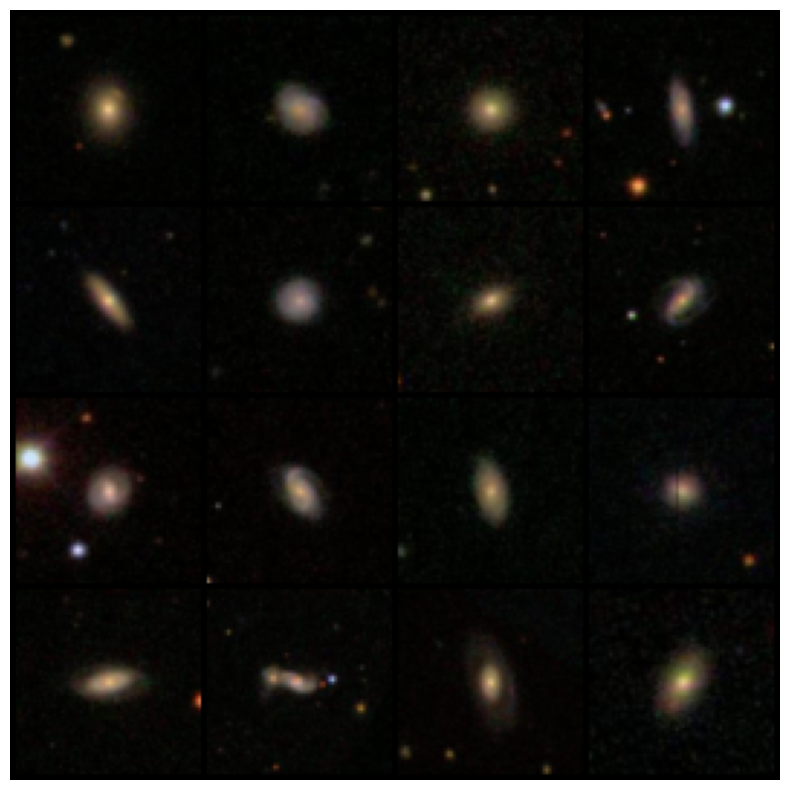


--- Galaxy Classifications (Left-to-Right, Top-to-Bottom) ---
Row 1: ['elliptical', 'spiral', 'elliptical', 'spiral']
Row 2: ['spiral', 'spiral', 'elliptical', 'spiral_barred']
Row 3: ['spiral_barred', 'spiral_barred', 'spiral', 'elliptical']
Row 4: ['elliptical', 'spiral_barred', 'spiral_barred', 'elliptical']


In [34]:
# TODO: un-normalise, make_grid(images[:16], nrow=4), permute, imshow, axis off.
import torchvision
import matplotlib.pyplot as plt

# 1. Grab the first 16 images and labels from the batch we generated in Step 7
images_to_plot = images_batch[:16]
labels_to_plot = labels_batch[:16]

# 2. Undo the normalization (images * std + mean)
unnorm_images = images_to_plot * 0.5 + 0.5

# 3. Create a clean grid of images (4 images per row)
grid = torchvision.utils.make_grid(unnorm_images, nrow=4)

# 4. Permute the dimensions for matplotlib: (C, H, W) -> (H, W, C)
# We also call .numpy() because matplotlib operates on numpy arrays, not tensors
grid_image = grid.permute(1, 2, 0).numpy()

# 5. Plot the grid!
plt.figure(figsize=(10, 10))
plt.imshow(grid_image)
plt.axis('off')
plt.show()

# --- BONUS: Print the class names ---
# We use label.item() to extract the standard Python integer from the PyTorch scalar tensor
class_names = [dataset.classes[label.item()] for label in labels_to_plot]

print("\n--- Galaxy Classifications (Left-to-Right, Top-to-Bottom) ---")
for i in range(0, 16, 4):
    print(f"Row {i//4 + 1}: {class_names[i:i+4]}")

## Stretch Goals *(optional)*

See [`09-project-task.md`](../09-project-task.md) for full descriptions:

1. Make a reproducible train/val split with `random_split` (seed it!).
2. Compute the **real** per-channel mean/std of the training set and use those in `Normalize`.
3. Plot several examples of each class side by side; guess which two will confuse a model.
4. Add `RandomHorizontalFlip` + `RandomRotation(180)` to a *train-only* transform and watch a galaxy flip/rotate.

In [35]:
# TODO (optional): one or more stretch goals.

## Reflection *(write 2–3 sentences each)*

Answer the prompts from [`09-project-task.md`](../09-project-task.md):

1. Most confusing part of setup / the data pipeline, and how you resolved it.
2. Pick one galaxy class and describe what a CNN must detect to recognise it.
3. After viewing real batches: which two classes will be hardest to tell apart, and why?
4. Why so much effort on the data pipeline *before* any model?

*(
  
1. Most confusing part for me was to getting the dataset from the kaggle! I had to convert my API token into .json file so that I can retrieve the data!

2. For Spiral Galaxies, a CNN must detect low-level edge gradients to outline the sweeping, curved structures of the density-driven spiral arms.

3. Spiral barred and spirals! Because they look almost similar if the image isn't clear.

4. Because a machine learning model is completely blind without it; neural networks cannot process raw JPGs or unorganized data. The pipeline does the crucial heavy lifting of cleaning the data, matching images to their scientific labels, and transforming raw pixels into structured matrices (tensors) that a model can actually calculate and learn from. )*